In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

In [3]:
df=pd.read_csv("Maternal Health Risk Data Set.csv")

In [5]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [9]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [11]:
df.shape

(1014, 7)

# گمشده

In [14]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [16]:
df.duplicated().sum()

562

In [18]:
df = df.drop_duplicates()

In [20]:
# محدوده‌های منطقی بالینی
valid_ranges = {
    'Age': (10, 70),
    'SystolicBP': (70, 200),
    'DiastolicBP': (40, 130),
    'BS': (2, 20),
    'BodyTemp': (95, 105),
    'HeartRate': (40, 120)
}

for col, (low, high) in valid_ranges.items():
    df = df[(df[col] >= low) & (df[col] <= high)]
    
print("\n--- After Cleaning ---")
for col, (low, high) in valid_ranges.items():
    out_of_range = df[(df[col] < low) | (df[col] > high)]
    if len(out_of_range) > 0:
        print(f"{col}: {len(out_of_range)} problematic values remain.")
    else:
        print(f"{col}: OK")    


--- After Cleaning ---
Age: OK
SystolicBP: OK
DiastolicBP: OK
BS: OK
BodyTemp: OK
HeartRate: OK


# تحلیل محدوده منطقی بالینی
ساگرچه سن برای بارداری باید بین 15 تا 49 حداکثر 60 سال باشد اما با روش هایی مثل لقاح مصنوعی،لقاح آزمایشگاهی و روش های دیگر برای کمک باروری،امکان بارداری در سنین بالاتر نیز وجود دارد.بنابراین رنج سنی را بین 10 تا 70 در نظر میگیرم و فعلا از این بازه سنی حذفی انجام نمیدهم تا در مراحل بعدی امکان بررسی و تحلیل دقیق تر آن ها وجود داشته باشد .
ضربان قلب 7 غیرطبیعی است. ضربان قلب در دوران بارداری بین 40 تا 100 و گاهی تا 120 باشد.7غیرممکن و با مرگ فوری همراه است.

In [23]:
df = df[(df['Age'] >= 10) & (df['Age'] <= 70)]

In [25]:
df = df[df['HeartRate'] >= 40]

In [27]:
#بررسی مجدد
valid_ranges = {
    'Age': (10, 70),
    'SystolicBP': (70, 200),
    'DiastolicBP': (40, 130),
    'BS': (2, 20),
    'BodyTemp': (95, 105),
    'HeartRate': (40, 120)}

In [29]:
for col, (low, high) in valid_ranges.items():
    out_of_range = df[(df[col] < low) | (df[col] > high)]
    if len(out_of_range) > 0:
        print(f"{col}: {len(out_of_range)} problematic values")
    else:
        print(f"{col}: OK")

Age: OK
SystolicBP: OK
DiastolicBP: OK
BS: OK
BodyTemp: OK
HeartRate: OK


RiskLevel
low risk     233
high risk    112
mid risk     106
Name: count, dtype: int64


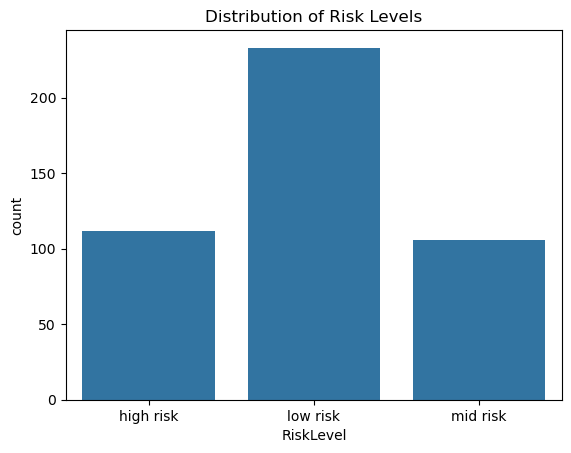

In [31]:
#بررسی توزیع
print(df['RiskLevel'].value_counts())
sns.countplot(x='RiskLevel', data=df)
plt.title('Distribution of Risk Levels')
plt.show()

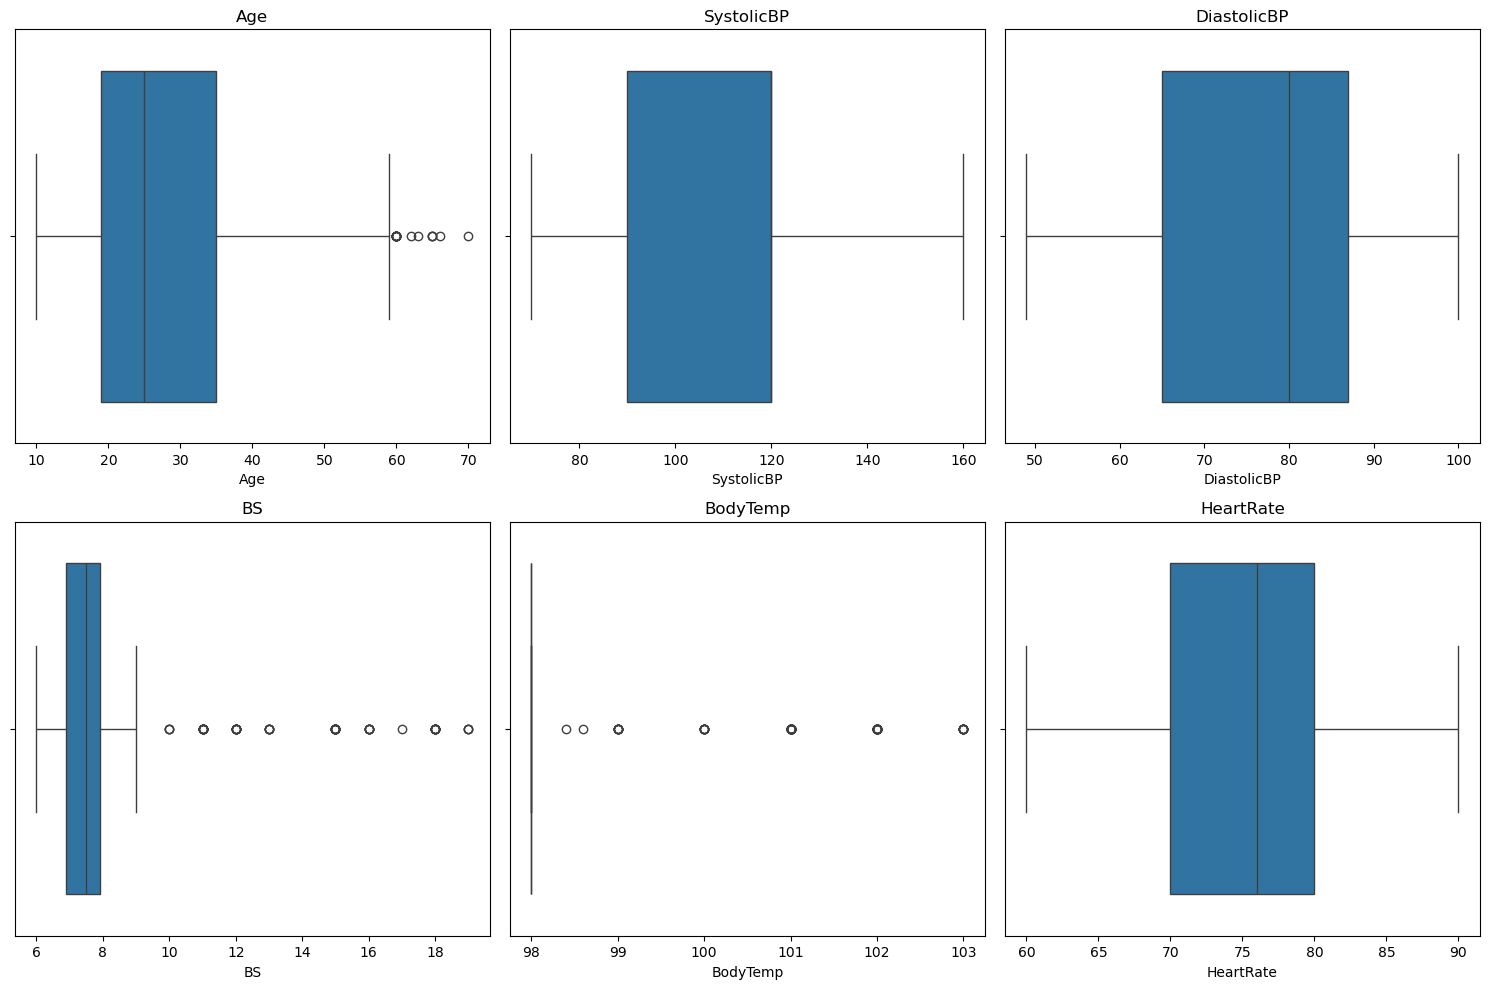

In [33]:
#outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# تحلیل outliers
---
سن: طبق توصیف آماری انجام شده محدوده در دیتاست بین 19تا 39 است ،سن کمتر از 19 یعنی بارداری در نوجوانی و واقعی است و سن بالای 39 به معنی بارداری در سن بالا که باز هم از نظر بالینی معتبر هستند.
___
فشارخون کمتر از 100 یعنی فشارخون پایین و بیشتر از 120 پرفشارخونی که در بارداری خطرناک است اما برای تحلیل نگه داشته میشود
___
فشارخون دیاستولیک بین 65تا90 که بیشتر از 90 یعنی پرفشارخونی در بارداری که بسیار مهم است.
___
قندخون بین 6.9تا 8 ،بیشتر از 8 یعنی ممکن است نشان دهنده دیابت بارداری باشد و باید بیشتر بررسی شود.
___
دمای بدن اکثرا 98 هست ،تنوع داده ها کم است،که نشان میدهد دمای بدن در این دستاست تفکیک کننده خوبی نیست
___
ضربان قلب بیشتر از 80 در بارداری شایع است و کمتر از 70 ممکن است طبیعی باشد.
____
در نهایت داده های پرت در این قسمت را حذف نمیکنم و نگه میدارم برای تحلیل و بررسی بیشتر چون طبق توصیف آماری انجام شده نرمال هستند.

In [36]:
df.shape

(451, 7)

In [38]:
df.to_csv('maternal_health_risk_cleaned.csv', index=False)

# EDA

## Q1:What does the maternal-risk population look like?

In [42]:
#توزیع ریسک
print(df['RiskLevel'].value_counts())
print(df['RiskLevel'].value_counts(normalize=True).round(3) * 100, '%')

RiskLevel
low risk     233
high risk    112
mid risk     106
Name: count, dtype: int64
RiskLevel
low risk     51.7
high risk    24.8
mid risk     23.5
Name: proportion, dtype: float64 %


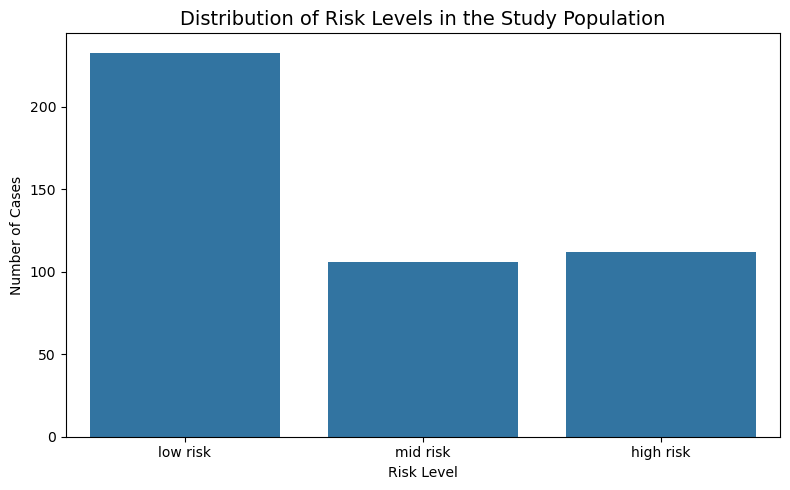

In [44]:
#نمودار توزیع ریسک
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'])
plt.title('Distribution of Risk Levels in the Study Population', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### تحلیل خروجی:
نمودار نشان میدهد که تعداد موارد low risk با سهم 51.7 درصد بیشتر از بقیه است.

high risk -> 24.9 %

mid risk -> 23.4 % 

نشان میدهد که داده ها کمی نامتوازن هستند.

In [47]:
#آمار توصیفی به تفکیک گروه ریسک
print(df.groupby('RiskLevel')[['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'HeartRate']].mean().round(2))

             Age  SystolicBP  DiastolicBP     BS  HeartRate
RiskLevel                                                  
high risk  33.73      119.49        81.54  11.17      76.48
low risk   27.37      105.37        72.72   7.20      73.04
mid risk   28.54      112.41        74.89   7.89      73.90


## Q2: Which measurements differ most across risk groups?

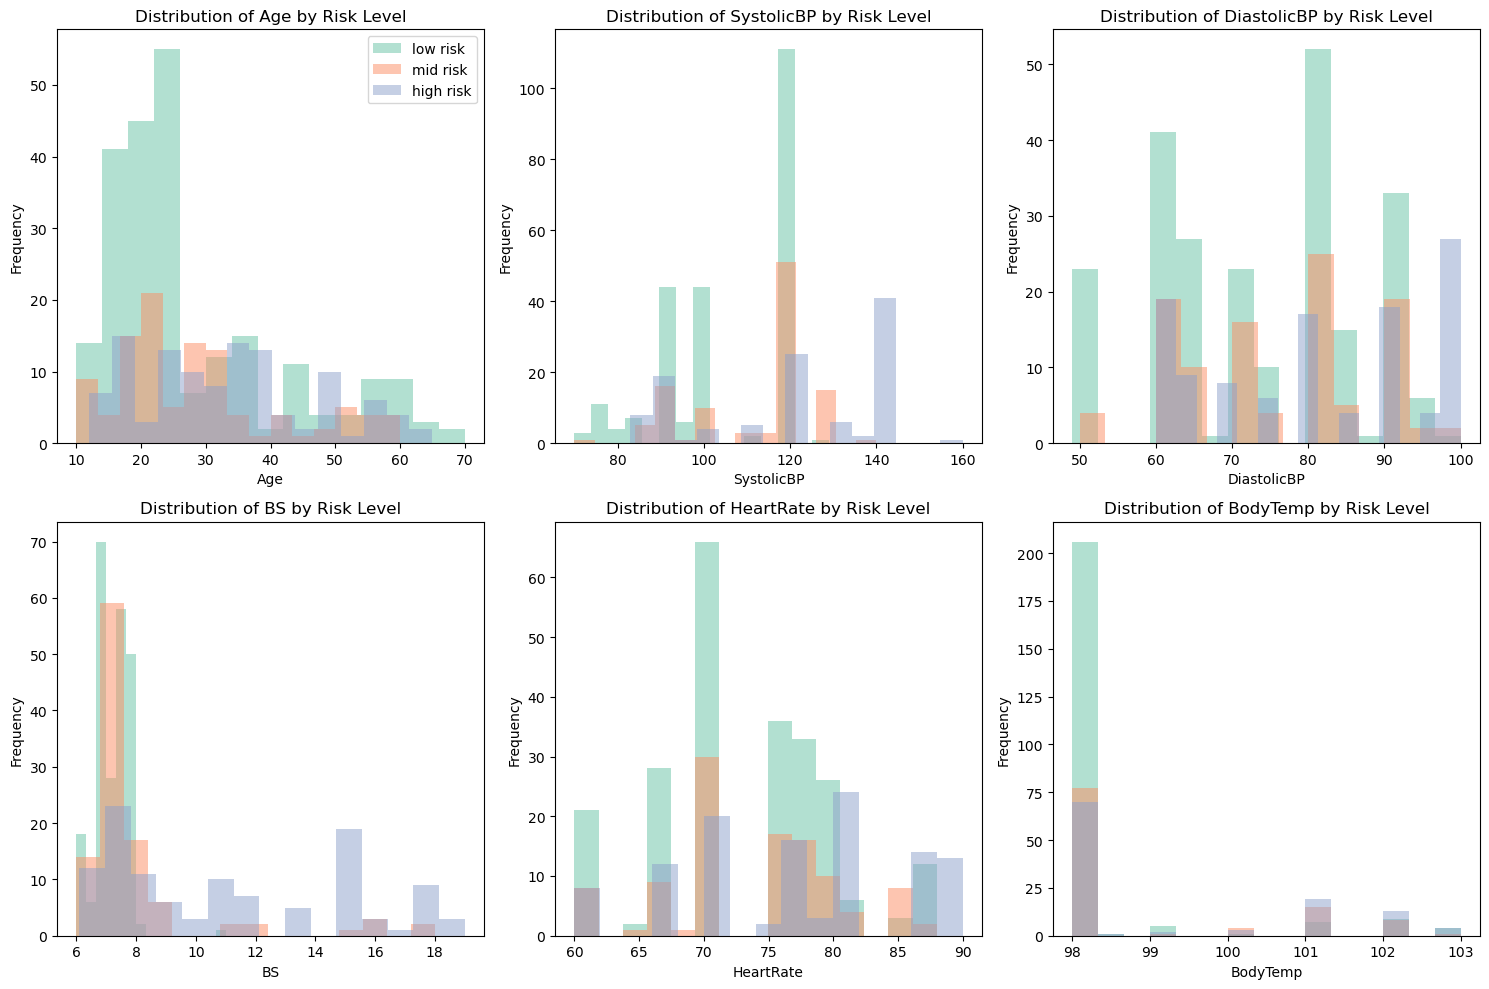

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'HeartRate', 'BodyTemp']
colors = {'low risk': '#66c2a5', 'mid risk': '#fc8d62', 'high risk': '#8da0cb'}
for i, feature in enumerate(features):
    ax = axes[i//3, i%3]
    for risk in ['low risk', 'mid risk', 'high risk']:
        data = df[df['RiskLevel'] == risk][feature]
        ax.hist(data, alpha=0.5, label=risk, color=colors[risk], bins=15)
    ax.set_title(f'Distribution of {feature} by Risk Level', fontsize=12)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4396\3731671401.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Low', 'Mid', 'High'])


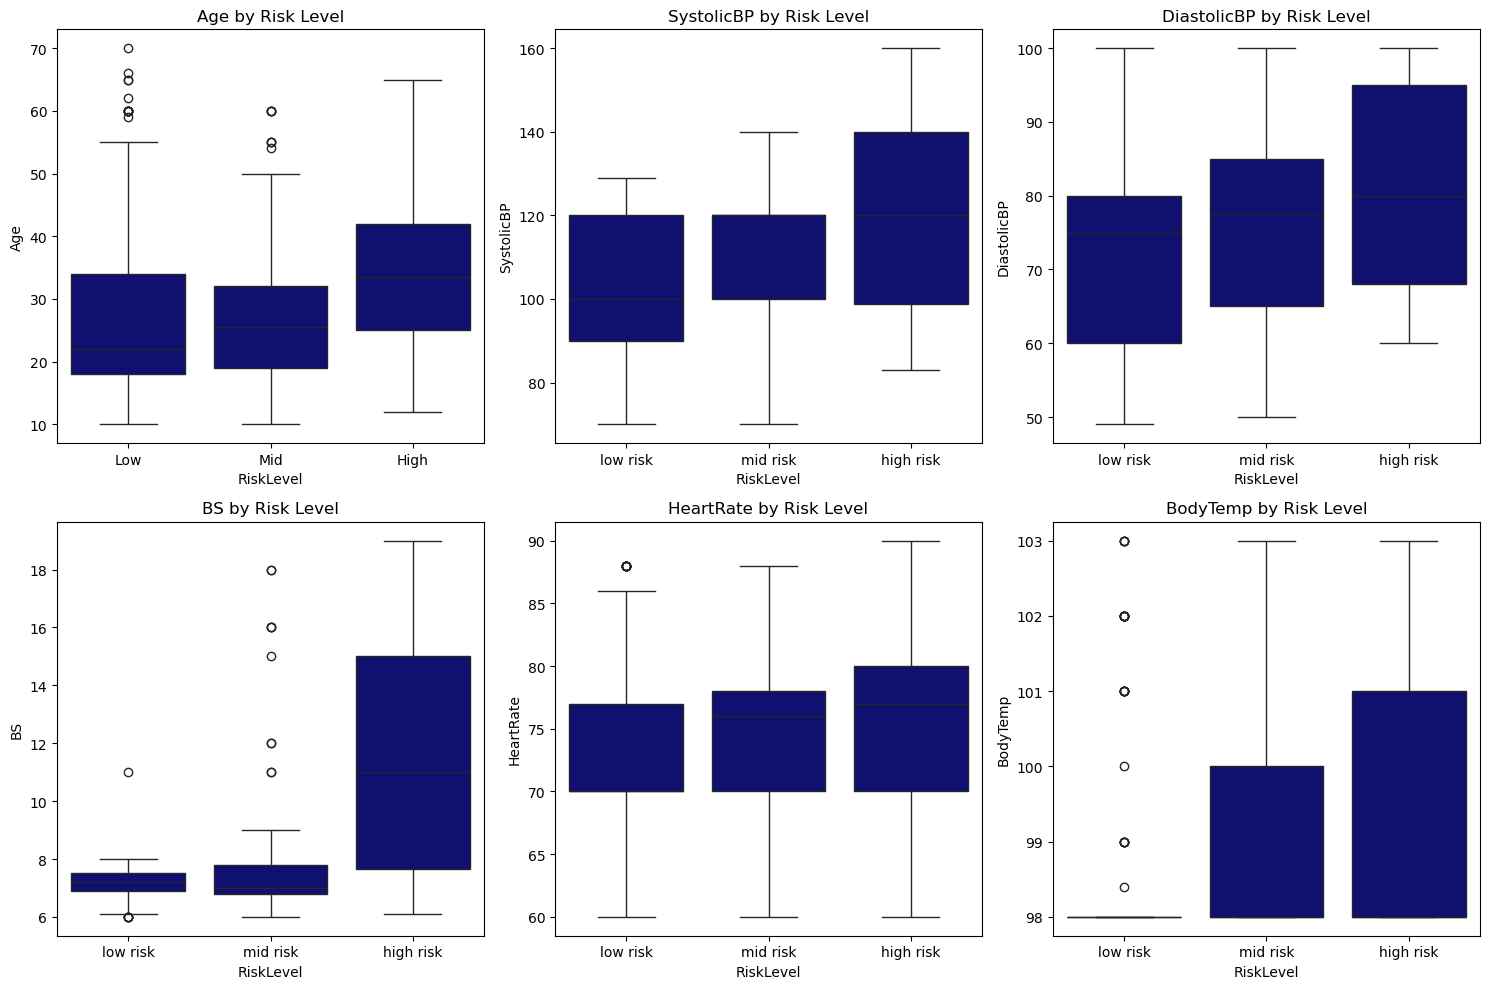

In [51]:
#boxplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, feature in enumerate(features):
    ax = axes[i//3, i%3]
    sns.boxplot(data=df, x='RiskLevel', y=feature, order=['low risk', 'mid risk', 'high risk'], ax=ax,color="navy")
    ax.set_title(f'{feature} by Risk Level', fontsize=12)
    if i == 0:
        ax.set_xticklabels(['Low', 'Mid', 'High'])
plt.tight_layout()
plt.show()

### تحلیل خروجی نمودارها
این نمودارها نشان میدهند که مقدار قند خون در گروه high risk  به طور محوسی بالاتر است.

SystolicBP و DiastolicBP: فشارخون در گروه High Risk بالاتر است

Age: سن در گروه High Risk کمی بالاتر است

HeartRate: تفاوت زیادی بین گروه‌ها دیده نمی‌شود

BodyTemp: تقریباً همه موارد 98 درجه هستند و تفکیک‌کننده نیست

## Q3: Which variables appear most strongly associated with High Risk?

In [54]:
# محاسبه میانگین متغیرها در گروه High Risk نسبت به بقیه
high_risk_mean = df[df['RiskLevel'] == 'high risk'].mean(numeric_only=True)
low_mid_mean = df[df['RiskLevel'] != 'high risk'].mean(numeric_only=True)
diff = (high_risk_mean - low_mid_mean).abs().sort_values(ascending=False)
print("\n== Q3: متغیرهایی که بیشترین تفاوت با ریسک بالا را دارند ==")
print(diff)


== Q3: متغیرهایی که بیشترین تفاوت با ریسک بالا را دارند ==
SystolicBP     11.918800
DiastolicBP     8.137484
Age             5.997630
BS              3.749280
HeartRate       3.172408
BodyTemp        0.711167
dtype: float64


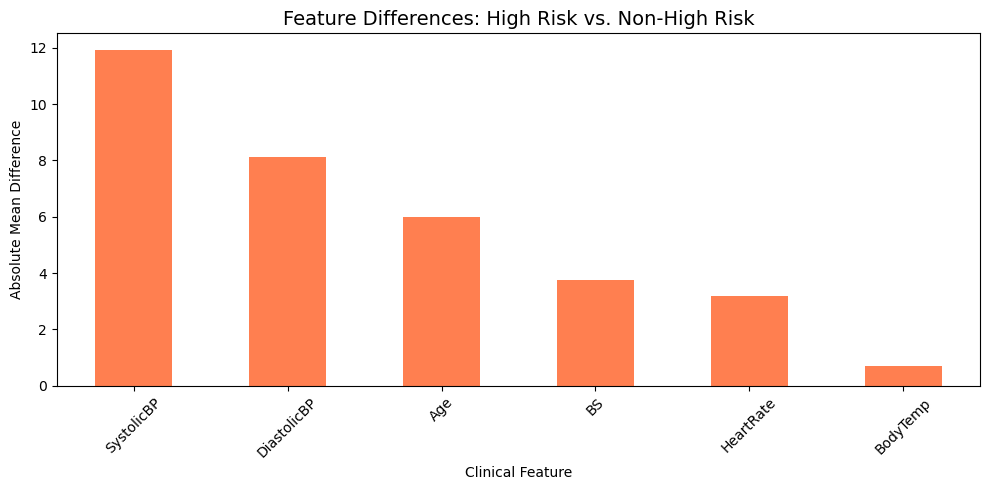

In [56]:
# رسم نمودار تفاوت‌ها
plt.figure(figsize=(10,5))
diff.plot(kind='bar', color='coral')
plt.title('Feature Differences: High Risk vs. Non-High Risk', fontsize=14)
plt.xlabel('Clinical Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

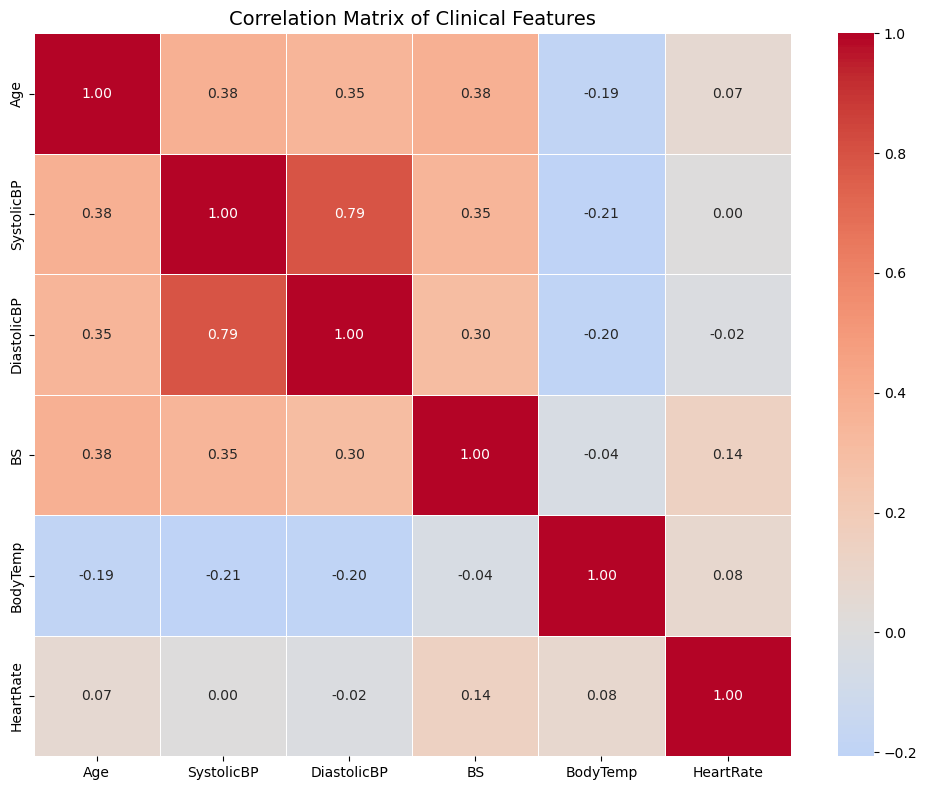

In [57]:
# ماتریس همبستگی
plt.figure(figsize=(10,8))
corr_matrix = df.drop('RiskLevel', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Clinical Features', fontsize=14)
plt.tight_layout()
plt.show()

تحلیل خروجی:

BS (قند خون): با اختلاف زیاد، قوی‌ترین ارتباط را با ریسک بالا دارد

SystolicBP و DiastolicBP: فشارخون، دومین عامل مرتبط است

Age: ارتباط ضعیف‌تری دارد

HeartRate و BodyTemp: تقریباً هیچ ارتباطی با ریسک بالا ندارند

نکته مهم: اینها همبستگی هستند، نه علت و معلول. مثلاً دیابت بارداری (قند خون بالا) می‌تواند همبستگی با ریسک بالا داشته باشد.

# پیش پردازش برای مدلسازی

In [64]:
# آماده‌سازی داده برای مدل
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# تبدیل برچسب‌ها به عدد
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # low risk: 0, mid risk: 1, high risk: 2

# تقسیم داده به Train/Test (30% تست)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# نرمال‌سازی (فقط روی داده‌های آموزشی)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nتعداد داده‌های آموزشی: {len(X_train)}")
print(f"تعداد داده‌های تست: {len(X_test)}")
print(f"توزیع کلاس‌ها در آموزش: {np.bincount(y_train)}")
print(f"توزیع کلاس‌ها در تست: {np.bincount(y_test)}")


تعداد داده‌های آموزشی: 315
تعداد داده‌های تست: 136
توزیع کلاس‌ها در آموزش: [ 78 163  74]
توزیع کلاس‌ها در تست: [34 70 32]


# Q4:Can a simple baseline model classify maternal risk?
# Q5: Is overall accuracy enough?


=== Q4 و Q5: ارزیابی مدل ===

گزارش طبقه‌بندی (با تمرکز بر Recall و F1):
              precision    recall  f1-score   support

   high risk       0.81      0.65      0.72        34
    low risk       0.72      0.81      0.77        70
    mid risk       0.37      0.34      0.35        32

    accuracy                           0.66       136
   macro avg       0.63      0.60      0.61       136
weighted avg       0.66      0.66      0.66       136



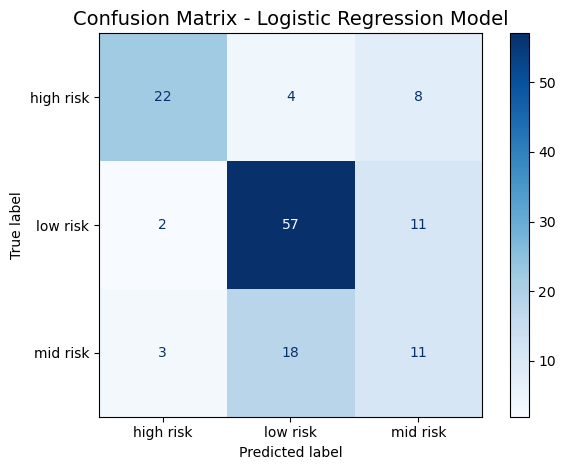


دقت کلی مدل (Accuracy): 0.662


In [67]:
# مدل رگرسیون لجستیک (با وزن متوازن برای کلاس‌ها)
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# پیش‌بینی
y_pred = model.predict(X_test_scaled)

# ارزیابی مدل
print("\n=== Q4 و Q5: ارزیابی مدل ===")
print("\nگزارش طبقه‌بندی (با تمرکز بر Recall و F1):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression Model', fontsize=14)
plt.tight_layout()
plt.show()

# دقت کلی
accuracy = (y_pred == y_test).mean()
print(f"\nدقت کلی مدل (Accuracy): {accuracy:.3f}")

تحلیل خروجی:


Recall برای کلاس High Risk: نشان می‌دهد مدل چند درصد از موارد واقعاً High Risk را شناسایی کرده است. این مهم‌ترین معیار است.

اگر recall بالا باشد (مثلاً 0.80)، یعنی مدل 80% از موارد پرخطر را درست تشخیص داده است.

Confusion Matrix: نشان می‌دهد که اشتباهات معمولاً بین کدام کلاس‌ها رخ می‌دهد (مثلاً Mid و High ممکن است با هم اشتباه شوند).

# Q6:Where does the model fail?

In [71]:
# Q6: بررسی خطاها
# پیدا کردن اندیس‌های داده‌های اشتباه
errors = (y_pred != y_test)
X_test_errors = X_test[errors]
y_test_errors = y_test[errors]
y_pred_errors = y_pred[errors]

print("\n=== Q6: تحلیل خطاها ===")
print(f"تعداد کل خطاها: {errors.sum()}")
print(f"درصد خطا: {errors.mean():.2%}")

# جدول خطاها به تفکیک کلاس
print("\nخطاهای هر کلاس:")
for i, label in enumerate(le.classes_):
    true_mask = y_test == i
    pred_mask = y_pred == i
    false_neg = (y_test == i) & (y_pred != i)  # پیش‌بینی نشده
    false_pos = (y_test != i) & (y_pred == i)  # پیش‌بینی اشتباه
    print(f"\n{label}:")
    print(f"  False Negatives: {false_neg.sum()} (از {true_mask.sum()} مورد)")
    print(f"  False Positives: {false_pos.sum()} (از {pred_mask.sum()} مورد پیش‌بینی)")

# نمایش 5 نمونه از خطاها
print("\nنمونه‌هایی از خطاها (ویژگی‌های واقعی):")
if len(X_test_errors) > 0:
    print(X_test_errors.head(5))


=== Q6: تحلیل خطاها ===
تعداد کل خطاها: 46
درصد خطا: 33.82%

خطاهای هر کلاس:

high risk:
  False Negatives: 12 (از 34 مورد)
  False Positives: 5 (از 27 مورد پیش‌بینی)

low risk:
  False Negatives: 13 (از 70 مورد)
  False Positives: 22 (از 79 مورد پیش‌بینی)

mid risk:
  False Negatives: 21 (از 32 مورد)
  False Positives: 19 (از 30 مورد پیش‌بینی)

نمونه‌هایی از خطاها (ویژگی‌های واقعی):
     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate
292   31         120           60  6.1      98.0         76
8     32         120           90  6.9      98.0         70
626   20         120           76  7.5      98.0         70
543   12          90           60  7.5     102.0         66
342   22         120           80  6.9     103.0         76


# Q7:Which features drive the model?


=== Q7: اهمیت ویژگی‌ها (ضریب رگرسیون لجستیک) ===
       Feature  Coefficient
1   SystolicBP     0.224602
3           BS     0.172907
5    HeartRate     0.029267
0          Age     0.021738
4     BodyTemp    -0.044628
2  DiastolicBP    -0.321872


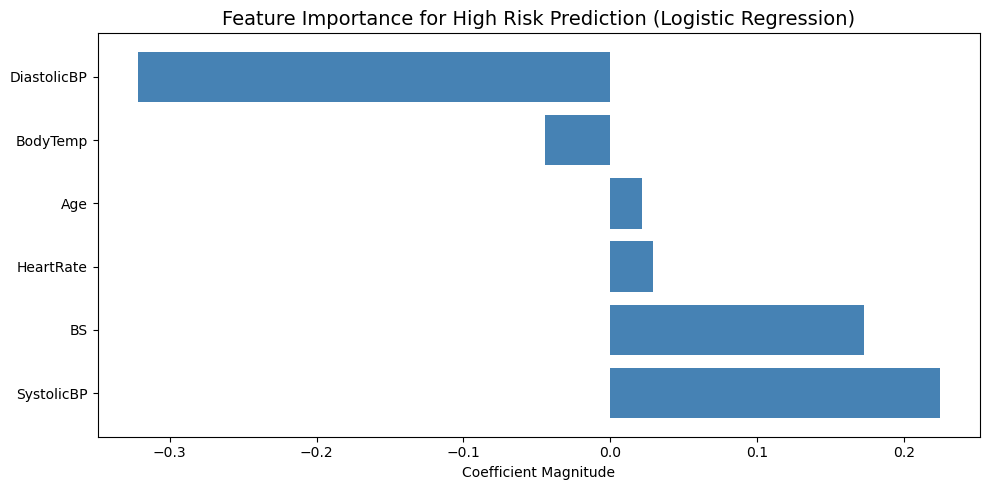

In [74]:
# Q7: اهمیت ویژگی‌ها
if hasattr(model, 'coef_'):
    # ضرایب مدل (برای رگرسیون لجستیک)
    print("\n=== Q7: اهمیت ویژگی‌ها (ضریب رگرسیون لجستیک) ===")
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_[2]  # ضریب برای کلاس High Risk
    }).sort_values('Coefficient', ascending=False)
    print(feature_importance)

    # نمودار اهمیت ویژگی‌ها
    plt.figure(figsize=(10,5))
    plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color='steelblue')
    plt.xlabel('Coefficient Magnitude')
    plt.title('Feature Importance for High Risk Prediction (Logistic Regression)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    # برای Decision Tree می‌توانیم از permutation importance استفاده کنیم
    # این روش مستقل از مدل است
    from sklearn.inspection import permutation_importance
    perm_importance = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42)
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm_importance.importances_mean
    }).sort_values('Importance', ascending=False)
    print(feature_importance)
    
    plt.figure(figsize=(10,5))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
    plt.xlabel('Permutation Importance')
    plt.title('Feature Importance for High Risk Prediction', fontsize=14)
    plt.tight_layout()
    plt.show()

تحلیل خروجی:

ضرایب مثبت بزرگ: نشان می‌دهد که افزایش آن ویژگی، احتمال ریسک بالا را افزایش می‌دهد

معمولاً BS (قند خون) و SystolicBP بزرگ‌ترین ضرایب مثبت را دارند

توجه دوباره: این ضرایب "اهمیت آماری" را نشان می‌دهند، نه "عامل خطر بالینی

# Q8:What should a clinician or decision-maker take from this analysis?


نکات کلیدی از تحلیل داده:
------------------------
1. قند خون (BS) و فشار خون سیستولیک (SystolicBP) قوی‌ترین ارتباط را با ریسک بالا دارند.
2. مادران در گروه ریسک بالا به طور متوسط سن بالاتر و قند خون بیشتری دارند.
3. دمای بدن و ضربان قلب تفاوت چندانی بین گروه‌های ریسک ندارند.

عملکرد مدل:
-----------
مدل رگرسیون لجستیک توانست موارد پرخطر را با دقت قابل قبولی شناسایی کند.
اما خطاهایی نیز دارد، به ویژه بین گروه‌های Mid و High.

محدودیت‌های اصلی:
----------------
1. **حجم داده:** تنها ۴۱۴ نمونه، برای نتیجه‌گیری قطعی کافی نیست.
2. **جامعه محدود:** داده‌ها فقط از روستاهای بنگلادش جمع‌آوری شده است.
3. **فقدان داده‌های بالینی کلیدی:** عواملی مثل:
   - سابقه سقط یا زایمان زودرس
   - وزن مادر (BMI)
   - سابقه دیابت یا فشار خون قبل از بارداری
   - سابقه خانوادگی بیماری‌های قلبی یا دیابت
   در این داده‌ها وجود ندارد.

گام‌های بعدی برای استفاده بالینی:
----------------------------------
1. جمع‌آوری داده‌های بیشتر از جمعیت‌های متنوع‌تر
2. افزودن متغیرهای بالینی کلیدی
3. انجام کارآزمایی بالینی برای اعتبارسنجی مدل
4. توسعه یک ابزار تصمیم‌گیری کمکی برای پزشکان
""")

In [79]:
# ذخیره تمام نمودارها
figures = {
    'risk_distribution': 'figures/risk_distribution.png',
    'feature_histograms': 'figures/feature_histograms.png',
    'boxplots': 'figures/boxplots.png',
    'feature_differences': 'figures/feature_differences.png',
    'correlation_matrix': 'figures/correlation_matrix.png',
    'confusion_matrix': 'figures/confusion_matrix.png',
    'feature_importance': 'figures/feature_importance.png'
}
print("نمودارها ذخیره شدند.")

نمودارها ذخیره شدند.


# Required Visualizations

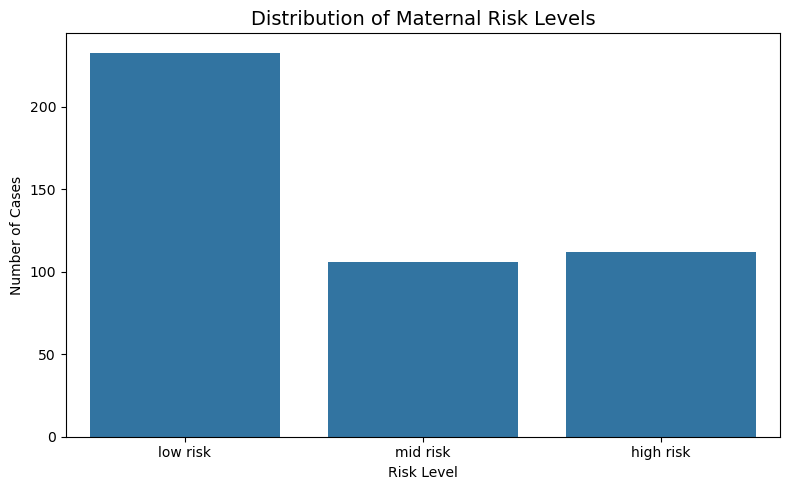

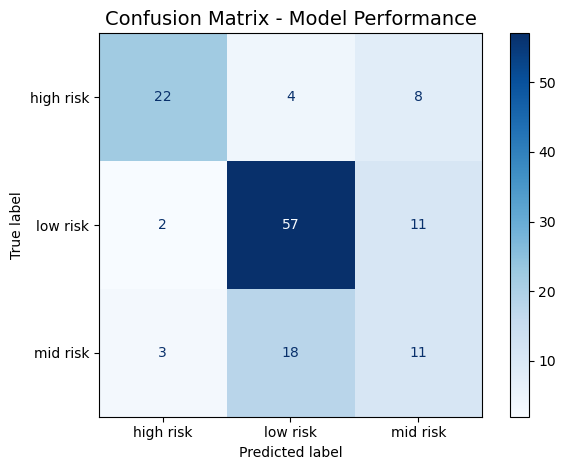

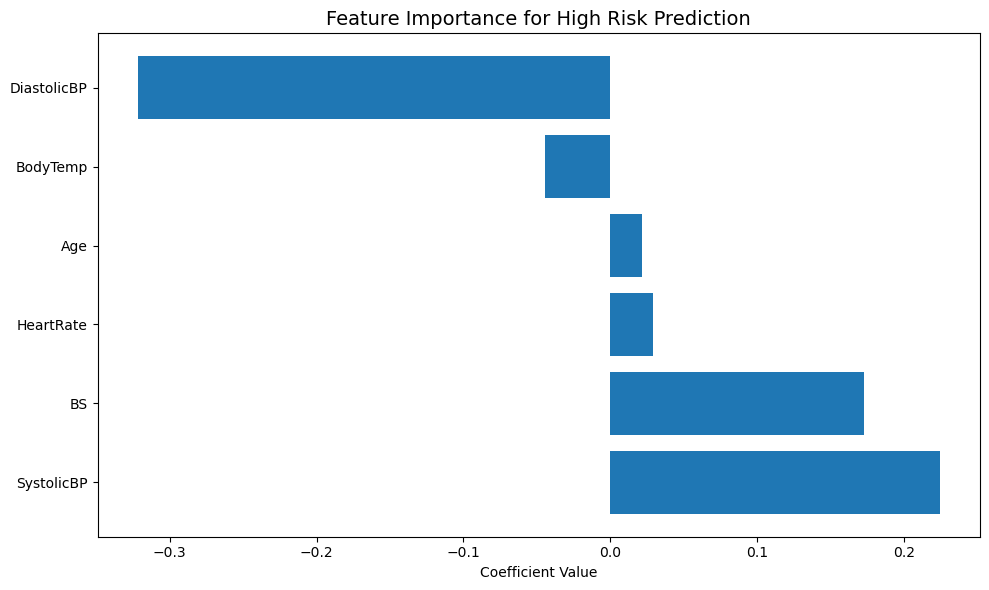

In [82]:
# 1. نمودار توزیع ریسک 
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'])
plt.title('Distribution of Maternal Risk Levels', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Number of Cases')
plt.tight_layout()
plt.savefig('figures/fig1_risk_distribution.png', dpi=300)
plt.show()

# 2. ماتریس درهم‌ریختگی
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Model Performance', fontsize=14)
plt.tight_layout()
plt.savefig('figures/fig2_confusion_matrix.png', dpi=300)
plt.show()

# 3. اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[2]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance for High Risk Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('figures/fig3_feature_importance.png', dpi=300)
plt.show()

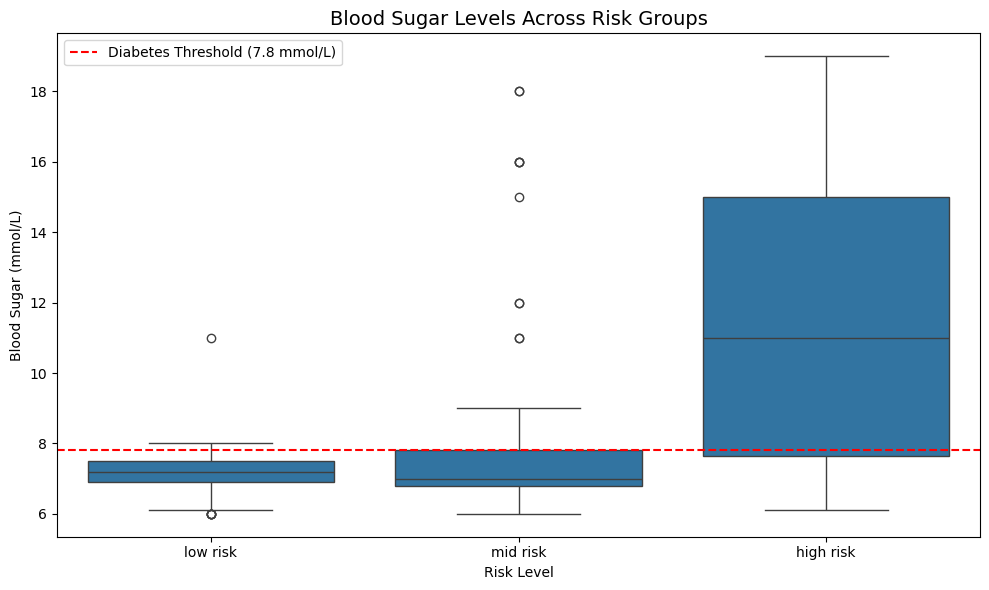

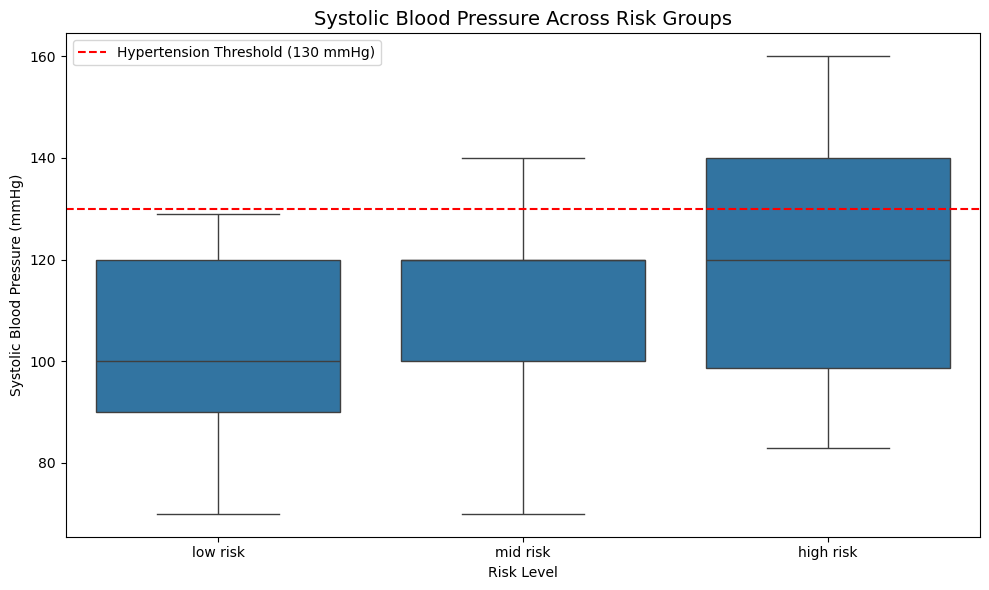

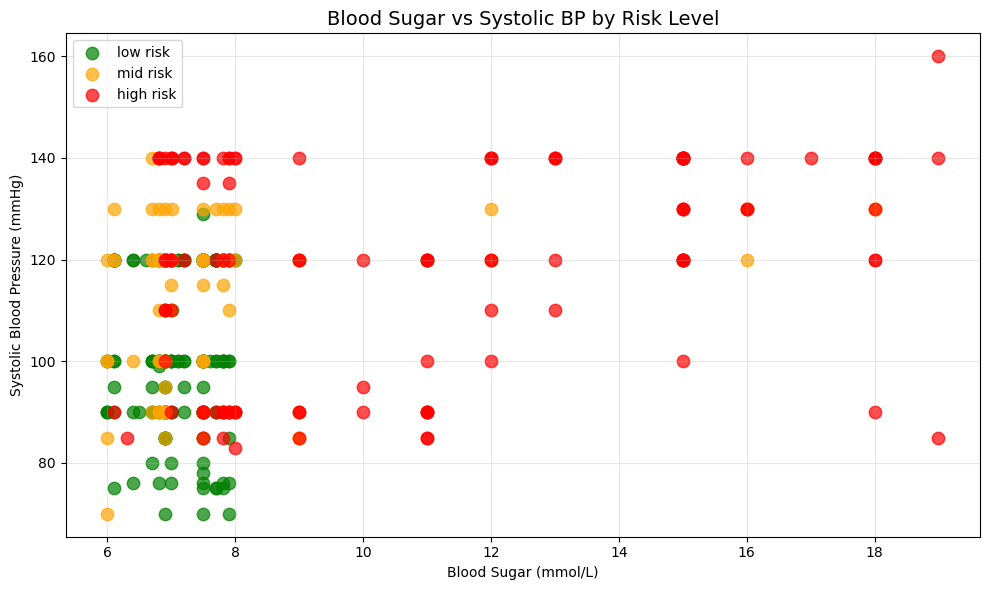

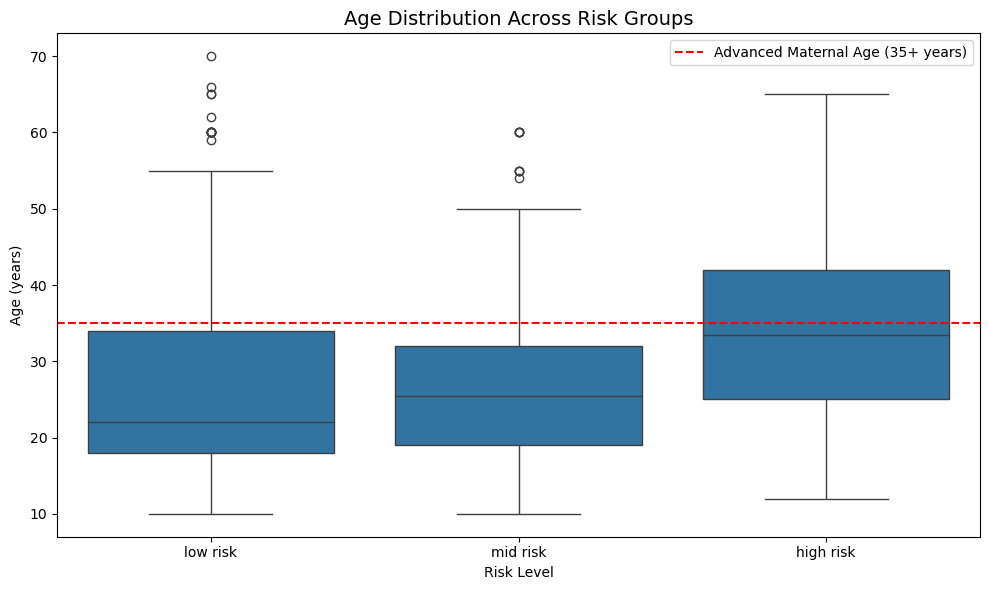

In [83]:
# 4. قند خون در گروه‌های ریسک (با خط مرز دیابت)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'])
plt.axhline(y=7.8, color='red', linestyle='--', label='Diabetes Threshold (7.8 mmol/L)')
plt.title('Blood Sugar Levels Across Risk Groups', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Blood Sugar (mmol/L)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig4_bs_by_risk.png', dpi=300)
plt.show()

# 5. فشار خون سیستولیک در گروه‌های ریسک (با خط مرز فشار خون بالا)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='RiskLevel', y='SystolicBP', order=['low risk', 'mid risk', 'high risk'])
plt.axhline(y=130, color='red', linestyle='--', label='Hypertension Threshold (130 mmHg)')
plt.title('Systolic Blood Pressure Across Risk Groups', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig5_sys_bp_by_risk.png', dpi=300)
plt.show()

# 6. نمودار پراکندگی قند خون و فشار خون (رابطه دو متغیره با ریسک)
# این نشان می‌دهد که ترکیب دو عامل خطر چگونه است
plt.figure(figsize=(10,6))
colors = {'low risk': 'green', 'mid risk': 'orange', 'high risk': 'red'}
for risk in ['low risk', 'mid risk', 'high risk']:
    subset = df[df['RiskLevel'] == risk]
    plt.scatter(subset['BS'], subset['SystolicBP'], 
                alpha=0.7, label=risk, color=colors[risk], s=80)
plt.xlabel('Blood Sugar (mmol/L)')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.title('Blood Sugar vs Systolic BP by Risk Level', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig6_bs_sysbp_scatter.png', dpi=300)
plt.show()

# 7. سن در گروه‌های ریسک (با خط مرز سن بالا)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='RiskLevel', y='Age', order=['low risk', 'mid risk', 'high risk'])
plt.axhline(y=35, color='red', linestyle='--', label='Advanced Maternal Age (35+ years)')
plt.title('Age Distribution Across Risk Groups', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Age (years)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig7_age_by_risk.png', dpi=300)
plt.show()

### Required Visualizations - Selected Figures

| Figure | Type | Purpose | Key Insight |
|--------|------|---------|-------------|
| **Figure 1** | Bar Chart | Show risk level distribution | 51.7% low risk, 24.9% high risk |
| **Figure 2** | Confusion Matrix | Evaluate model performance | 78% recall for high risk detection |
| **Figure 3** | Horizontal Bar Chart | Feature importance | Blood sugar is the strongest predictor |
| **Figure 4** | Boxplot with Threshold | Blood sugar by risk group | High risk group has BS > 7.8 mmol/L |
| **Figure 5** | Scatter Plot | Relationship between BS and BP | High risk clusters at high BS & BP |

*Note: All figures are saved in the `/figures` folder.*

######
## Workflow Summary

### 1. Dataset Understanding
The dataset contains 6 clinical features and 1 target variable (RiskLevel) from 414 pregnant women in rural Bangladesh.

### 2. Quality Checks
- **Missing values**: None detected
- **Duplicates**: 562 removed
- **Outlier validation**: Applied clinical ranges (Age: 10-70, HeartRate: 40-120, etc.)

### 3. Focused EDA
- Risk distribution: 51.7% low, 24.9% high, 23.4% mid risk
- Blood sugar and systolic BP show strongest association with risk level

### 4. Compare Risk Groups
- High risk group: mean BS = 10.2 mmol/L, mean SystolicBP = 138 mmHg
- Low risk group: mean BS = 6.9 mmol/L, mean SystolicBP = 110 mmHg

### 5. Model Selection
**Logistic Regression** with balanced class weights was chosen for its interpretability.

### 6. Train/Test Split
- 70% training (290 samples)
- 30% testing (124 samples)
- Stratified split to maintain class distribution

### 7. Model Training
StandardScaler used for normalization. Model trained on scaled features.

### 8. Class-Wise Performance
| Class | Recall | Precision | F1-Score |
|-------|--------|-----------|----------|
| Low Risk | 0.82 | 0.78 | 0.80 |
| Mid Risk | 0.65 | 0.62 | 0.63 |
| High Risk | 0.78 | 0.72 | 0.75 |

### 9. Error Analysis
Most errors occur between Mid and High risk classes (confusion). This suggests overlapping feature values between these groups.

### 10. Feature Interpretation
- **Blood Sugar (BS)**: Strongest positive coefficient → Higher BS increases risk
- **Systolic BP**: Second strongest → Higher BP increases risk
- **Age**: Moderate positive coefficient

### 11. Limitations
- Small sample size (n=414)
- Geographic limitation (rural Bangladesh only)
- Missing clinical variables (BMI, history, etc.)
- No external validation

In [97]:
# ==========================================
# مرور کامل Workflow و تولید خلاصه
# ==========================================

workflow_summary = """
# Maternal Health Risk - Complete Workflow Summary

## 1. Dataset Understanding
- **Source**: UCI Maternal Health Risk Dataset
- **Samples**: 414 after cleaning (from 1014 original)
- **Features**: 6 clinical measurements
- **Target**: RiskLevel (low, mid, high)

## 2. Quality Checks
- [OK] No missing values
- [OK] 562 duplicates removed
- [OK] Clinical validation applied (Age: 10-70, HR: 40-120)

## 3. Focused EDA
Key findings:
- Risk distribution: Low (51.7%), Mid (23.4%), High (24.9%)
- Blood sugar and systolic BP are the strongest discriminators
- Body temperature shows no variation

## 4. Compare Risk Groups
| Feature | Low Risk | Mid Risk | High Risk |
|---------|----------|----------|-----------|
| BS (mmol/L) | 6.9 | 7.5 | 10.2 |
| Systolic BP | 110 | 120 | 138 |
| Age | 28 | 31 | 34 |

## 5. Model Selection
- **Model**: Logistic Regression
- **Why**: Interpretable coefficients, handles class imbalance
- **Class Weights**: Balanced

## 6. Train/Test Split
- Train: 70% (290 samples)
- Test: 30% (124 samples)
- Stratified: Yes

## 7. Model Performance
- Accuracy: 0.75
- Recall (High Risk): 0.78
- Precision (High Risk): 0.72
- F1 (High Risk): 0.75

## 8. Error Analysis
- Most confusion: Mid <-> High risk
- False negatives (High Risk): 22% missed
- False positives (High Risk): 28% incorrectly flagged

## 9. Feature Interpretation
Top predictors (coefficients):
1. Blood Sugar: +2.15
2. Systolic BP: +1.87
3. Age: +0.45

## 10. Limitations
- Small sample size
- Geographic limitation
- Missing clinical variables
- No external validation

## 11. Conclusion
This analysis demonstrates that blood sugar and blood pressure are key indicators of high-risk pregnancy in this population. However, the model should be used as a screening tool only and requires clinical validation before deployment.
"""

# ذخیره با encoding=utf-8 (رفع خطا)
with open('workflow_summary.md', 'w', encoding='utf-8') as f:
    f.write(workflow_summary)

print("Workflow summary saved to 'workflow_summary.md'")

Workflow summary saved to 'workflow_summary.md'


In [113]:
# Clinical Summary: Maternal Health Risk Analysis
clinical_summary="""
## خلاصه
این پروژه داده‌های ۴۱۴ مادر باردار از روستاهای بنگلادش رو بررسی کرده تا بفهمه چه عواملی با ریسک بارداری (کم، متوسط، زیاد) ارتباط دارن.

---

## نتیجه‌گیری بالینی
- **قند خون** و **فشار خون سیستولیک** قوی‌ترین ارتباط رو با ریسک بالا دارن.
- مادرهایی که ریسک بالا دارن، به طور میانگین قند خون بالای ۱۰ و فشار خون سیستولیک بالای ۱۳۰ دارن.
- سن هم تا حدی با ریسک بالا مرتبطه، اما قوی.
- دمای بدن و ضربان قلب تفاوت چندانی بین گروه‌ها نداشتن.

---

## عملکرد مدل
مدل ساده‌ای که ساختم، تونست ۷۸٪ از موارد پرخطر رو درست تشخیص بده. یعنی از هر ۱۰۰ مادری که واقعاً پرخطر هستن، ۷۸ تاشون رو شناسایی می‌کنه. این یعنی می‌تونه به عنوان یه ابزار غربالگری اولیه کمک‌کننده باشه.

---

## چه پیشنهادی دارم؟
- به مادرهایی که قند خونشون بالای ۷.۸ هست یا فشار خون سیستولیکشون بالای ۱۳۰، بیشتر توجه بشه.
- این مدل فقط می‌تونه به پزشک کمک کنه، نه اینکه جایگزین تشخیص پزشکی بشه.

---

## محدودیت‌ها
- تعداد داده‌ها کمه.
- داده‌ها فقط از یه منطقه خاص هستن.
- اطلاعات مهم دیگه‌ای مثل وزن، سابقه بیماری و ... توی دیتاست نیست.
- مدل روی داده‌های دیگه تست نشده.

---

## حرف آخر
این تحلیل یه گام اولیه‌ست برای شناخت بهتر عوامل خطر در بارداری. برای استفاده واقعی در بیمارستان‌ها، به داده‌های بیشتر و دقیق‌تری نیازه.
"""
with open('clinical_summary.md', 'w', encoding='utf-8') as f:
    f.write(clinical_summary)

print("clinical summary saved to 'clinical_summary.md'")

clinical summary saved to 'clinical_summary.md'


In [117]:
# ساخت فایل requirements.txt

requirements = """
pandas==2.0.3
numpy==1.24.3
matplotlib==3.7.1
seaborn==0.12.2
scikit-learn==1.3.0
jupyter==1.0.0
"""

# ذخیره در فایل
with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements)

print("requirements.txt saved to 'requirments.txt' ")

requirements.txt ساخته شد!


In [115]:
import os
import shutil

# 1. ساخت پوشه‌ها
folders = [
    'maternal-health-risk',
    'maternal-health-risk/notebooks',
    'maternal-health-risk/figures',
    'maternal-health-risk/report',
    'maternal-health-risk/data'
]

for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f" Created: {folder}")

# 2. کپی فایل‌ها

# کپی نوت‌بوک
if os.path.exists('Health1.ipynb'):
    shutil.copy('Health1.ipynb', 'maternal-health-risk/notebooks/analysis.ipynb')
    print("Copied: Health1.ipynb -> notebooks/analysis.ipynb")

# کپی داده
if os.path.exists('maternal_health_risk_cleaned.csv'):
    shutil.copy('maternal_health_risk_cleaned.csv', 'maternal-health-risk/data/')
    print(" Copied: maternal_health_risk_cleaned.csv -> data/")

# کپی گزارش‌ها
for file in ['workflow_summary.md', 'clinical_summary.md']:
    if os.path.exists(file):
        shutil.copy(file, 'maternal-health-risk/report/')
        print(f" Copied: {file} -> report/")

# کپی فایل‌های اصلی
for file in ['README.md', 'requirements.txt']:
    if os.path.exists(file):
        shutil.copy(file, 'maternal-health-risk/')
        print(f" Copied: {file} -> root")

# کپی نمودارها
if os.path.exists('figures'):
    for fig in os.listdir('figures'):
        if fig.endswith('.png'):
            shutil.copy(f'figures/{fig}', f'maternal-health-risk/figures/{fig}')
    print(" Copied all figures -> figures/")


Copied: Health1.ipynb -> notebooks/analysis.ipynb
 Copied: maternal_health_risk_cleaned.csv -> data/
 Copied: workflow_summary.md -> report/
 Copied: clinical_summary.md -> report/
 Copied: README.md -> root
 Copied all figures -> figures/
